In [1]:
!pip3 install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 10.2 MB/s eta 0:00:00


In [21]:
#Install and connect

import logging
from pymongo import MongoClient
from pymongo.server_api import ServerApi
import pandas as pd
import numpy as np

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)

MONGO_URI = "mongodb+srv://<username>:<password>@cluster0.zkz187c.mongodb.net/?appName=Cluster0"

try:
    client = MongoClient(MONGO_URI, server_api=ServerApi("1"))
    db = client["wildfire_project"]
    client.admin.command("ping")
    logger.info(f"Connected. Collections: {db.list_collection_names()}")
    print("Connected. Collections:", db.list_collection_names())
except Exception as e:
    logger.error(f"MongoDB connection failed: {e}")
    raise

Connected. Collections: ['wildfires']


In [14]:
# Data preparation: query MongoDB into a dataframe
try:
    cursor = db.wildfires.find({}, {
        "_id":           0,
        "fire_year":     1,
        "discovery_doy": 1,
        "cause":         1,
        "size_class":    1,
        "location":      1,
        "weather":       1,
        "topography":    1,
    })

    records = []
    for doc in cursor:
        row = {
            "fire_year":          doc.get("fire_year"),
            "discovery_doy":      doc.get("discovery_doy"),
            "cause":              doc.get("cause"),
            "size_class":         doc.get("size_class"),
            "latitude":           doc.get("location", {}).get("latitude"),
            "longitude":          doc.get("location", {}).get("longitude"),
            "temp_max_c":         doc.get("weather", {}).get("temp_max_c"),
            "wind_speed_ms":      doc.get("weather", {}).get("wind_speed_ms"),
            "relative_humidity":  doc.get("weather", {}).get("relative_humidity"),
            "vpd_kpa":            doc.get("weather", {}).get("vpd_kpa"),
            "precip_mm":          doc.get("weather", {}).get("precip_mm"),
            "elevation_m":        doc.get("topography", {}).get("elevation_m"),
            "slope_deg":          doc.get("topography", {}).get("slope_deg"),
            "aspect_deg":         doc.get("topography", {}).get("aspect_deg"),
        }
        records.append(row)

    df = pd.DataFrame(records)
    logger.info(f"Loaded {len(df):,} records from MongoDB.")
    print(f"Loaded {len(df):,} records from MongoDB.")
    print(df["size_class"].value_counts())
    df.head()
except Exception as e:
    logger.error(f"Failed to load data from MongoDB: {e}")
    raise

Loaded 7,000 records from MongoDB.
size_class
small     6735
large      135
medium     130
Name: count, dtype: int64


In [15]:
#Feature engineering
from sklearn.preprocessing import LabelEncoder

try:
    # Encode cause as numeric
    df["cause_encoded"] = LabelEncoder().fit_transform(df["cause"].fillna("Unknown"))

    FEATURES = [
        "fire_year", "discovery_doy",
        "latitude", "longitude",
        "elevation_m", "slope_deg", "aspect_deg",
        "cause_encoded",
    ]

    TARGET = "size_class"

    df = df.dropna(subset=[TARGET])
    df = df[df[TARGET].isin(["small", "medium", "large"])]

    X = df[FEATURES]
    y = df[TARGET]

    logger.info(f"Feature matrix shape: {X.shape}")
    print(f"Dataset shape: {X.shape}")
    print(y.value_counts())
except KeyError as e:
    logger.error(f"Missing column: {e} — check FEATURES list.")
    raise
except Exception as e:
    logger.error(f"Feature engineering failed: {e}")
    raise

Dataset shape: (7000, 8)
size_class
small     6735
large      135
medium     130
Name: count, dtype: int64


In [16]:
#Random 80/20 stratified split
from sklearn.model_selection import train_test_split

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    logger.info(f"Train: {len(X_train):,} records, Test: {len(X_test):,} records")
    print(f"Training set: {len(X_train):,} records")
    print(f"Test set:     {len(X_test):,} records")
    print(f"\nTrain class distribution:\n{y_train.value_counts()}")
    print(f"\nTest class distribution:\n{y_test.value_counts()}")
except Exception as e:
    logger.error(f"Train/test split failed: {e}")
    raise

Training set: 5,600 records
Test set:     1,400 records

Train class distribution:
size_class
small     5388
large      108
medium     104
Name: count, dtype: int64

Test class distribution:
size_class
small     1347
large       27
medium      26
Name: count, dtype: int64


In [17]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

try:
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ))
    ])
    pipeline.fit(X_train, y_train)
    logger.info("Random Forest model trained successfully.")
    print("Model trained.")
except Exception as e:
    logger.error(f"Model training failed: {e}")
    raise

Model trained.


In [18]:
#Evaluate model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    y_pred = pipeline.predict(X_test)
    acc = round(accuracy_score(y_test, y_pred), 4)
    logger.info(f"Model accuracy: {acc}")
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["large", "medium", "small"]))
except Exception as e:
    logger.error(f"Model evaluation failed: {e}")
    raise

Accuracy: 0.9336

Classification Report:
              precision    recall  f1-score   support

       large       0.17      0.37      0.23        27
      medium       0.00      0.00      0.00        26
       small       0.97      0.96      0.97      1347

    accuracy                           0.93      1400
   macro avg       0.38      0.44      0.40      1400
weighted avg       0.94      0.93      0.93      1400



## Analysis Rationale

I chose a Random Forest classifier for three reasons. First, Random
Forest handles mixed feature types (numeric, encoded categorical) without
requiring feature scaling, which suits our dataset where features like
fire_year and slope_deg operate on very different scales. Second, it
naturally handles missing values when combined with median imputation,
which is important because weather features are only available for a
subset of records. Third, Random Forest provides feature importances out
of the box, which gives us interpretable insight into which variables
drive fire size — important for communicating results to non-technical
stakeholders like fire managers.

A random 80/20 train/test split was used rather than a time based split because of the amount of data available for the years prior and after 2016 was not comparable.

class_weight was set to equal balanced because small fires vastly outnumber large fires in the dataset. Without this, the model would achieve high accuracy simply by predicting "small" for everything, which is useless for emergency managers. Balancing the class weights forces the model to learn to distinguish medium and large fires even when they are rare.

Median imputation was also used for missing weather values rather than
dropping those records, because dropping would remove the majority of our
dataset. Median imputation is conservative. It pulls missing values
toward the center of the distribution rather than making assumptions about extreme conditions.

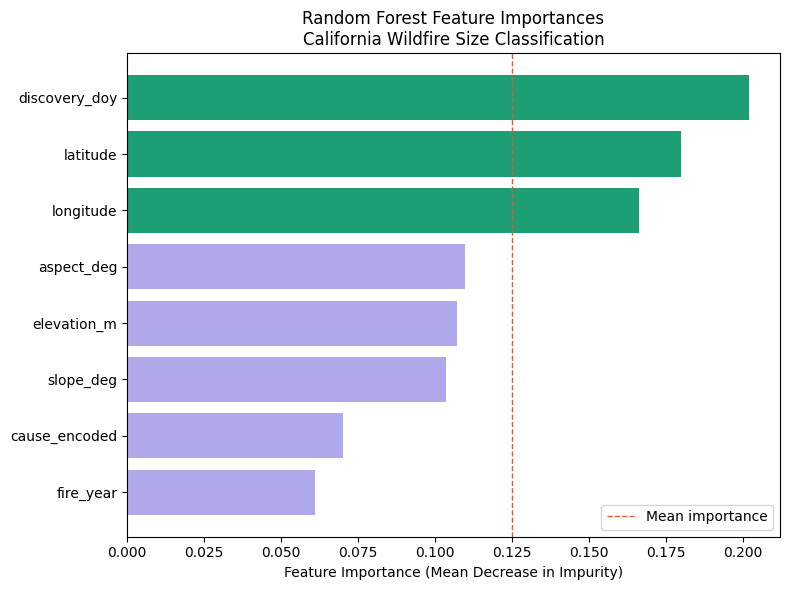

In [19]:
#Feature importance visualization
import matplotlib.pyplot as plt

try:
    importances = pipeline.named_steps["model"].feature_importances_
    feat_df = pd.DataFrame({
        "feature":    FEATURES,
        "importance": importances
    }).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#1D9E75" if i >= len(feat_df) - 3 else "#AFA9EC"
              for i in range(len(feat_df))]
    ax.barh(feat_df["feature"], feat_df["importance"], color=colors)
    ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
    ax.set_title("Random Forest Feature Importances\nCalifornia Wildfire Size Classification")
    ax.axvline(x=feat_df["importance"].mean(), color="#e05c2a",
               linestyle="--", linewidth=1, label="Mean importance")
    ax.legend()
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=140)
    plt.show()
    logger.info("Feature importance chart saved.")
except Exception as e:
    logger.error(f"Feature importance chart failed: {e}")
    raise

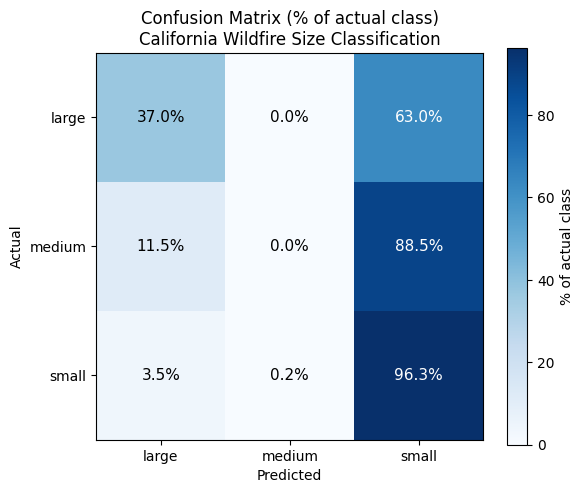

In [20]:
#Confusion matrix visualization
import numpy as np

try:
    labels = ["large", "medium", "small"]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_pct, cmap="Blues")
    plt.colorbar(im, ax=ax, label="% of actual class")

    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix (% of actual class)\nCalifornia Wildfire Size Classification")

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm_pct[i,j]:.1f}%",
                    ha="center", va="center",
                    color="white" if cm_pct[i,j] > 50 else "black", fontsize=11)

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=140)
    plt.show()
    logger.info("Confusion matrix saved.")
except Exception as e:
    logger.error(f"Confusion matrix failed: {e}")
    raise

## Visualization Rationale

The feature importance bar chart shows which variables the Random Forest relied on most when making predictions. This is the most important visualization for a non-technical audience because it answers the intuitive question: "what makes a fire big?" A horizontal bar chart was chosen over a pie chart or table because it makes ranking immediately visible and labels are easy to read at any length.

The confusion matrix shows where the model succeeds and fails across
the three size classes. We display percentages of actual class rather than raw counts because the classes are imbalanced. Raw counts would make the small-fire cells dominate visually and obscure performance on the more consequential large-fire class. The confusion matrix is particularly important for this problem because the cost of errors is asymmetric: failing to flag a large fire as large is far more dangerous than over-flagging a small fire.